# Reduccion de matrices con SymPy (operacion por operacion)

Vamos a resolver el sistema dado por rec¿ducción y operaciones elementales:

$$
\begin{align*}
2x + y - z &= 8 \\
-3x - y + 2z &= -11 \\
-2x + y + 2z &= -3
\end{align*}
$$

In [1]:
from sympy import Matrix, Rational, init_printing

init_printing()  # para que las matrices se vean bonitas en el notebook

## Matriz aumentada $[A \mid b]$

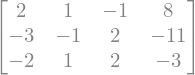

In [12]:
M = Matrix([
    [ 2,  1, -1,   8],
    [-3, -1,  2, -11],
    [-2,  1,  2,  -3]
])
M

## Paso 1: hacer el pivote de la fila 1 igual a 1

$R_1 \to \frac{1}{2} R_1$

Cada fila de una matriz de `sympy` se puede tomar con `M[i, :]` y reemplazar con `M[i, :] = ...`. Como `sympy` trabaja con fracciones exactas, no hay redondeos.

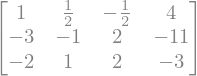

In [13]:
M[0, :] = M[0, :] / 2
M

## Paso 2: eliminar la columna 1 debajo del pivote

$R_2 \to R_2 + 3R_1$

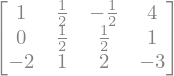

In [14]:
M[1, :] = M[1, :] + 3 * M[0, :]
M

$R_3 \to R_3 + 2R_1$

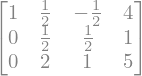

In [15]:
M[2, :] = M[2, :] + 2 * M[0, :]
M

## Paso 3: hacer el pivote de la fila 2 igual a 1

$R_2 \to 2R_2$

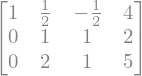

In [16]:
M[1, :] = 2 * M[1, :]
M

## Paso 4: eliminar la columna 2 debajo del pivote

$R_3 \to R_3 - 2R_2$

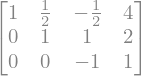

In [17]:
M[2, :] = M[2, :] - 2 * M[1, :]
M

## Paso 5: hacer el pivote de la fila 3 igual a 1

$R_3 \to -R_3$

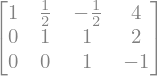

In [18]:
M[2, :] = -1 * M[2, :]
M

Ya tenemos la forma escalonada (unos en la diagonal, ceros debajo). Ahora falta la parte de "Jordan": eliminar hacia **arriba** para dejar ceros tambien por encima de cada pivote.

## Paso 6: eliminar la columna 3 encima del pivote

$R_2 \to R_2 - R_3$

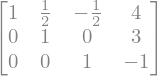

In [19]:
M[1, :] = M[1, :] - M[2, :]
M

$R_1 \to R_1 + \frac{1}{2}R_3$

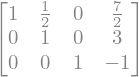

In [20]:
M[0, :] = M[0, :] + Rational(1, 2) * M[2, :]
M

## Paso 7: eliminar la columna 2 encima del pivote

$R_1 \to R_1 - 	\frac{1}{2}R_2$

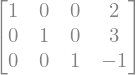

In [21]:
M[0, :] = M[0, :] -  M[1, :]/2
M

## Resultado

La matriz quedo como $[I \mid x]$, asi que la ultima columna es directamente la solucion: $x = 2$, $y = 3$, $z = -1$.

# Un ejercicio de la clase (5 de agosto)

La compañía Sunrise Porcelain fabrica tazas y platos de cerámica. Para cada taza o plato
un trabajador mide una cantidad fija de material y la pone en la máquina que los forma,
de donde pasa al vidriado y secado automático. En promedio, un trabajador necesita tres
minutos para iniciar el proceso de una taza y dos minutos para el de un plato. El material
para una taza cuesta $¢25$ y el material para un plato cuesta $¢20$. Si se asignan $\$44$ diarios
para la producción de tazas y platos, ¿cuántos deben fabricarse de cada uno en un día
de trabajo de 8 horas, si un trabajador se encuentra trabajando cada minuto y se gastan
exactamente $\$44$ en materiales?

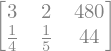

In [30]:
B = Matrix([[3, 2, 480], [Rational(1,4), Rational(1,5), 44]])
B

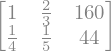

In [31]:
B[0,:] = B[0,:]/3
B

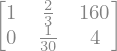

In [32]:
B[1,:] = B[1,:] - B[0,:]/4
B

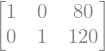

In [33]:
B[1,:] = 30*B[1,:]
B[0,:] = B[0,:] - 2*B[1,:]/3
B

La respuesta es $$x = 80, y = 120$$

# Ejercicios propuestos

## Ejercicios de multiplicación de matrices

### Ejercicio 1

Calcula el producto $AB$ para

$$
A = \begin{bmatrix} 2 & 0 & -1 \\ 1 & 3 & 4 \end{bmatrix}, \qquad
B = \begin{bmatrix} 1 & 2 \\ 0 & -1 \\ 3 & 1 \end{bmatrix}
$$

Hazlo primero a mano y luego verifica el resultado con `sympy`.

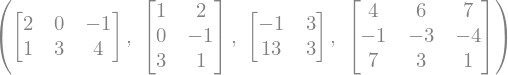

In [5]:
# Ejercicio 1: define A y B y calcula A*B
A = Matrix([[2,0,-1], [1,3,4]])
B = Matrix([[1,2], [0, -1], [3,1]])
A, B, A*B, B*A

### Ejercicio 2

Calcula el producto $AB$ para

$$
A = \begin{bmatrix} 1 & 2 & 0 \\ -1 & 1 & 3 \\ 2 & 0 & 1 \end{bmatrix}, \qquad
B = \begin{bmatrix} 0 & 1 & 2 \\ 1 & 0 & -1 \\ 3 & 2 & 1 \end{bmatrix}
$$

¿Es $AB = BA$? Verifícalo calculando también $BA$.

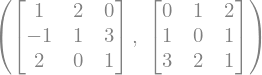

In [9]:
# Ejercicio 2: define A y B, y calcula A*B y B*A
A, B = Matrix([[1,2,0], [-1,1,3], [2,0,1]]), Matrix([[0,1,2], [1,0,1], [3,2,1]])
A, B

### Ejercicio 3

Una empresa vende dos productos, $P_1$ y $P_2$, en tres ciudades. La matriz $A$ da las
unidades vendidas de cada producto (filas) en cada ciudad (columnas), y la matriz $B$ da
la utilidad por unidad (filas: producto, columna única: utilidad en miles de pesos y $A^T$ es la matriz transpuesta de $A$ que cambia filas por columnas):

$$
A = \begin{bmatrix} 120 & 80 & 150 \\ 60 & 100 & 90 \end{bmatrix}, \qquad
B = \begin{bmatrix} 5 \\ 8 \end{bmatrix}
$$

Calcula $A^T B$ y explica qué representa cada entrada del resultado.

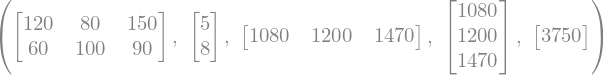

In [18]:
# Ejercicio 3: define A y B, y calcula A.T * B
A, B, C = Matrix([[120, 80, 150], [60, 100, 90]]), Matrix([[5], [8]]), Matrix([[1,1,1]])
A, B,  B.T*A, (A.T)*B,  C*(A.T)*B

## Ejercicios para plantear un sistema de ecuaciones

### Ejercicio 4

Un cine vende boletos de adulto y de niño. El boleto de adulto cuesta \$12.000 y el de
niño \$7.000. Un día se vendieron 150 boletos en total y se recaudaron \$1.400.000.
Además, se sabe que la cantidad de boletos de adulto vendidos fue el doble que la de
niños más 15.

Plantea el sistema de ecuaciones (tres ecuaciones, dos incógnitas si sobra una condición,
o ajusta las incógnitas que consideres necesarias) que describe la situación y escríbelo
como una matriz aumentada con `sympy`. No es necesario resolverlo todavía.

In [ ]:
# Ejercicio 4: escribe la matriz aumentada del sistema


### Ejercicio 5

Una fábrica produce tres tipos de muebles: sillas, mesas y estantes. Cada silla requiere
2 horas de carpintería y 1 hora de acabado; cada mesa requiere 3 horas de carpintería y 2
horas de acabado; cada estante requiere 1 hora de carpintería y 3 horas de acabado. En una
semana la fábrica dispone de 100 horas de carpintería y 90 horas de acabado, y además sabe
que produce el doble de sillas que de estantes.

Plantea el sistema de ecuaciones que representa esta situación y escríbelo como matriz
aumentada con `sympy`. No es necesario resolverlo todavía.

In [ ]:
# Ejercicio 5: escribe la matriz aumentada del sistema


### Ejercicio 6

Un inversionista reparte \$20.000.000 entre tres fondos: A, B y C. El fondo A paga 4% de
interés anual, el B paga 6% y el C paga 8%. Al cabo de un año recibió \$1.180.000 de
intereses en total. Además, invirtió en el fondo C el triple de lo que invirtió en el
fondo A.

Plantea el sistema de ecuaciones que representa esta situación (usa $x$, $y$, $z$ para lo
invertido en A, B y C respectivamente) y escríbelo como matriz aumentada con `sympy`. No
es necesario resolverlo todavía.

In [ ]:
# Ejercicio 6: escribe la matriz aumentada del sistema
